## If working in Google Colab, Run this first
Run the cell below, at the start of every session. 
It downloads the course files to your Google Drive and keeps them up to date.
When you see \"Setup complete\", you are ready to run the rest of the notebook.

**Do not edit or save your work inside the `AIforMovementScience` folder.** 
Use **File > Save a copy in Drive** and work on your own copy.

In [ ]:
# [course-setup] Run this cell first, every session (or use Runtime > Run all)
import os, sys
os.chdir('/content')                      # start from a valid directory
from google.colab import drive
drive.mount('/content/drive')

REPO = '/content/drive/MyDrive/AIforMovementScience'
if os.path.isdir(REPO + '/.git'):
    # already downloaded before: just update it
    !git -C "$REPO" fetch origin main && git -C "$REPO" reset --hard origin/main
else:
    # first time, or a broken/partial copy: download a fresh copy
    !rm -rf "$REPO"
    !git clone https://github.com/dguari1/AIforMovementScience.git "$REPO"

WORKDIR = REPO + '/lectures'          # this notebook's folder in the course files
os.chdir(WORKDIR)
sys.path.insert(0, WORKDIR)           # so local .py files (e.g. FunctionExamples.py) import correctly
print('Setup complete. You can now run the rest of the notebook.')

## Linear Regression

When analyzing data, you will likely use existing implementations of the different machine learning and numerical optimization algorithms rather than writing your own. The existing code is often optimized for efficiency and speed, making it less resource-intensive, faster, and more likely to converge.

Several Python libraries have become part of the data science community and are used daily by thousands of researchers and practitioners to analyze their data. 

Probably, the best-known machine learning library is `scikit-learn`, a mature data science library with an extensive collection of algorithms for data processing, classification, regression, clustering, dimensionality reduction, and model selection. 

Scikit-learn is well integrated with NumPy, Pandas, and Matplotlib, so it will be easy to use if you are familiar with those libraries 


Text(0.5, 1.0, 'Linear Regression')

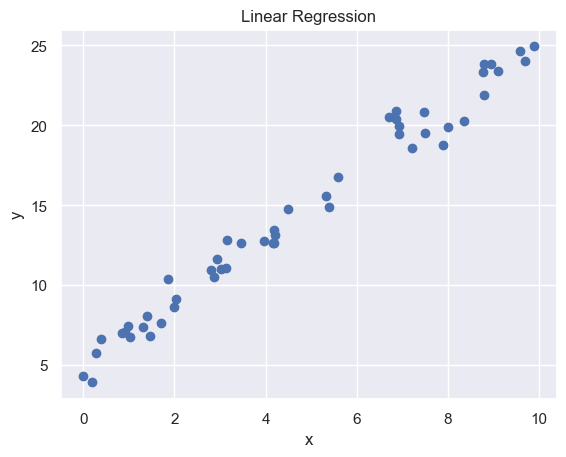

In [2]:
#we will start with a simple linear regression model using scikit-learn 
import numpy as np
np.set_printoptions(legacy='1.21') #this makes it easy to visualize some results, it is optional
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

#create a toy example with an independent variable, a dependent variable, and some noise
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 5 + 2 * x + 1*rng.randn(50)
plt.scatter(x, y);
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')

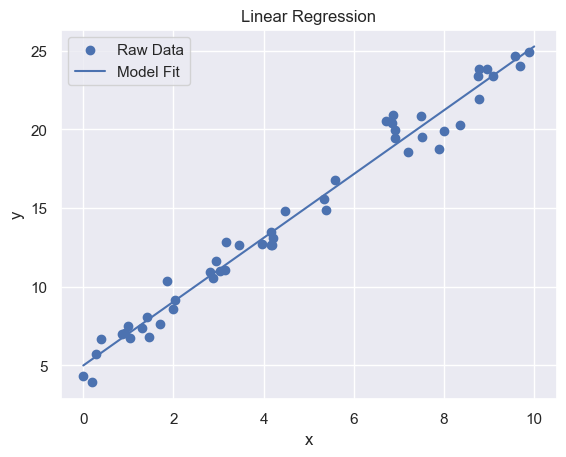

In [3]:
from sklearn.linear_model import LinearRegression
#notice that the Python package is called sklearn instead of scikit-learn 

#create a linear model, this is an empty shell for a linear model
model = LinearRegression(fit_intercept=True) # you can specify if you want to fit an intercept or not

#now that you have the model, you can fit the parameters using your data. This code will 
#run a version of gradient descent under the hood
model.fit(x.reshape(-1, 1),y.reshape(-1, 1))

#now that you 'fitted' the model (a.k.a identified the model parameters), you can make predictions with your model
xnew = np.linspace(0, 10, 1000)
ynew = model.predict(xnew[:, np.newaxis])

plt.scatter(x, y, label='Raw Data')
plt.plot(xnew, ynew, label='Model Fit');
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()


In [51]:
#you can also see the parameters estimated by the algorithm 
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)

Model slope:     [2.02720881]
Model intercept: [5.00142291]


The results are pretty close to our original values

$$
y = 5 + 2x
$$

__Activity__:
Change the level of noise and see when the optimization algorithm fails to find the model parameters 


## Model Validation 

So far, we have focused on how a model learns from data by adjusting its parameters to reduce prediction error. However, learning alone is not enough.

A critical question remains:

> How do we know whether a model will work on new, unseen data?

This notebook introduces the principles and tools used to evaluate models honestly and to avoid overly optimistic conclusions.

### Why Model Evaluation Is Necessary

A model can always be made to fit the data it has already seen—especially if it is flexible enough. However:

- Good performance on training data does not guarantee good performance on new data
- Complex models may memorize the training data instead of learning the relation between input and output data. This is called over-fitting.
- Without proper evaluation, we risk overfitting and false confidence

Model evaluation is about estimating generalization: how well a model performs on data it has never seen before.

### Three Different Roles for Data

As we will see in this notebook, to evaluate models correctly, we assign different roles to different subsets of the data:

- Training data: Used to learn the model parameters (e.g., slope and intercept)
- Validation data: Used during model development to compare models or tune hyperparameters
- Test data: Used once, at the very end, to estimate final performance on unseen data

Each dataset serves a different purpose. Be very careful, as mixing these roles leads to misleading results.

### Problem definition

After estimating the model parameters, it is essential to determine whether the model accurately describes the relationship between the input and output variables. 

Different methods can be used to test how good (or bad) our model is working; each approach has its advantages/disadvantages, and most people use a combination of different approaches to validate their models. 

Let's start by defining why we need to validate our models. Suppose you have the following dataset and you are interested in finding a model that fits the data and can help predict values for new datapoints 

<div style="text-align:center">
    <img src="images/test_linear_regression.png" alt="plot" width="400" />
</div>

You decide to try two models. The first is a simple linear model of the form
$$
y = \omega_0 + \omega_1x
$$

The second is a more complex linear model of the form 
$$
y = \omega_0 + \omega_1x + \omega_2x^2  + \omega_3x^3 + ... + \omega_{20}x^{20}
$$

Note: A polynomial model is still a linear model 

(-0.1, 1.0, -2.0, 14.0)

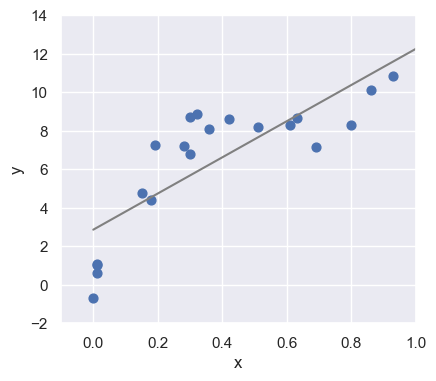

In [5]:
x = [0.3, 0.51, 0.36, 0.3, 0.18, 0.42, 0.19, 0.8, 0.93, 0.15, 0.63, 0.28, 0.32, 0.86, 0.01, 0.01, 0.0, 0.69, 0.61, 0.01]
y = [8.7, 8.2, 8.09, 6.8, 4.38, 8.59, 7.26, 8.29, 10.84, 4.79, 8.66, 7.22, 8.86, 10.13, 0.6, 1.01, -0.67, 7.15, 8.3, 1.08]

model1 = LinearRegression(fit_intercept=True) 
model1.fit(np.array(x).reshape(-1, 1),np.array(y).reshape(-1, 1))
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
yfit = model1.predict(xfit)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(x, y, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

(-0.1, 1.0, -2.0, 14.0)

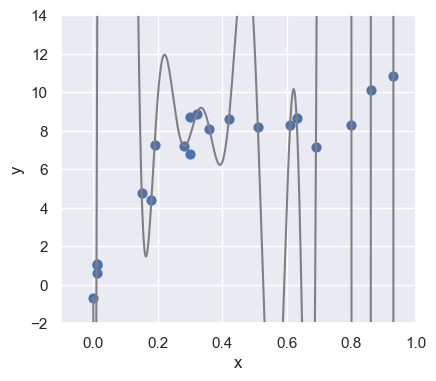

In [6]:
#create the input array
def create_array_for_poly(x,max_n=20):
    X = np.zeros((len(x), max_n+1)) #create a matrix with len(n) rows and max_n columns that will be filled 
    for n in range(0,max_n+1): #goes from 0 to max_n
        X[:,n] = (np.array(x).reshape(1,-1))**n #transform x into a column and put it in X
    return X

model2 = LinearRegression(fit_intercept=False) #the X matrix already has a column of 1 
X = create_array_for_poly(x) #create matrix with x and extra inputs 
model2.fit(X,np.array(y).reshape(-1, 1))
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
Xfit = create_array_for_poly(xfit)
yfit = model2.predict(Xfit)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(x, y, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

Clearly, none of those models seems correct. The first one seems to simple to describe the mesurements, while the second one seems to just follow the available datapoints. But how do we know which one to pick? 

### Validation data set
A potential strategy is to have a completely separate dataset that allows us to validate our model's goodness of fit. The **training** and **validation** datasets must be separated from the beginning of the training cycle to ensure there is no cross-contamination.
<div style="text-align:center">
    <img src="images/Full dataset.png" alt="plot" width="400" />
</div>

Once the data is divided, you can use the training data to estimate the model parameters and the validation data to assess the goodness of fit. Let's see how this procedure works in our dataset. 

The blue dots are used to train the model, while the red dots are used to evaluate it.
<div style="text-align:center">
    <img src="images/validation_set.png" alt="plot" width="400" />
</div>


#### What to evaluate?
In regression problems, a typical measure of goodness of fit is the $R^2$ score or coefficient of determination. This score measures how well the data predicted by our model agrees with the original data. An $R^2$ score of 1 indicates a perfect match between measures and predicted data, whereas an $R^2$ score of 0 indicates that the model does no better than simply taking the mean of the data. $R^2$ score can be negative, indicating that the model predictions are worse than taking the mean.

Note: $R^2$ score is sensitive to the dimensionality of the data, and it is common to use an adjusted version of the score that accounts for the number of independent variables in the model, called *Adjusted* $R^2$ score

Text(0.02, 0.91, 'validation score: $R^2$ = 0.81')

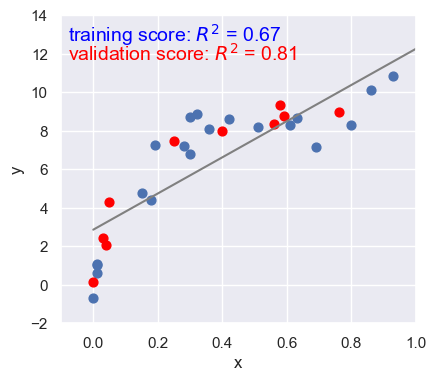

In [9]:
#training data
x_train = [0.3, 0.51, 0.36, 0.3, 0.18, 0.42, 0.19, 0.8, 0.93, 0.15, 0.63, 0.28, 0.32, 0.86, 0.01, 0.01, 0.0, 0.69, 0.61, 0.01]
y_train = [8.7, 8.2, 8.09, 6.8, 4.38, 8.59, 7.26, 8.29, 10.84, 4.79, 8.66, 7.22, 8.86, 10.13, 0.6, 1.01, -0.67, 7.15, 8.3, 1.08]


#validation data
x_val = [0.59, 0.0, 0.4, 0.56, 0.25, 0.05, 0.04, 0.58, 0.03, 0.76]
y_val = [8.77, 0.13, 8.01, 8.35, 7.48, 4.32, 2.05, 9.35, 2.41, 8.96]

#fit the model
model1 = LinearRegression(fit_intercept=True) 
model1.fit(np.array(x_train).reshape(-1, 1),np.array(y_train).reshape(-1, 1))
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
yfit = model1.predict(xfit)

#evaluate the model 
training_r2score = model1.score(np.array(x_train).reshape(-1, 1),np.array(y_train).reshape(-1, 1))
validation_r2score = model1.score(np.array(x_val).reshape(-1, 1),np.array(y_val).reshape(-1, 1))

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(x_train, y_train, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

ax.scatter(x_val, y_val, s=40, color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.02, 0.98, "training score: $R^2$ = {0:.2f}".format(training_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='blue')
ax.text(0.02, 0.91, "validation score: $R^2$ = {0:.2f}".format(validation_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='red')


Text(0.02, 0.91, 'validation score: $R^2$ = -7390.16')

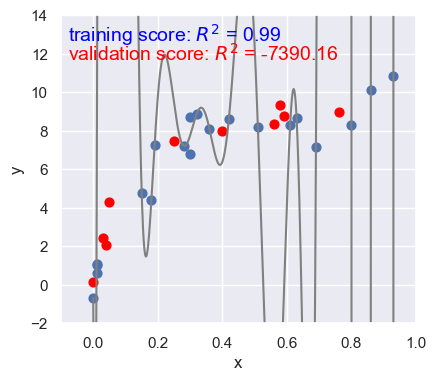

In [56]:
#fit the model
model2 = LinearRegression(fit_intercept=False) #the X matrix already has a column of 1 
X_train = create_array_for_poly(x_train) #create matrix with x and extra inputs 
model2.fit(X_train,np.array(y_train).reshape(-1, 1))
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
Xfit = create_array_for_poly(xfit)
yfit = model2.predict(Xfit)


#evaluate the model 
training_r2score = model2.score(X_train,np.array(y_train).reshape(-1, 1))
X_val = create_array_for_poly(x_val) #create matrix with x and extra inputs 
validation_r2score = model2.score(X_val,np.array(y_val).reshape(-1, 1))

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(x_train, y_train, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

ax.scatter(x_val, y_val, s=40, color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.02, 0.98, "training score: $R^2$ = {0:.2f}".format(training_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='blue')
ax.text(0.02, 0.91, "validation score: $R^2$ = {0:.2f}".format(validation_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='red')


We obtained the following results:

**Training set**
- Model 1, $R^2$ score = 0.67
- Model 2, $R^2$ score = 0.99

**Validation set**
- Model 1, $R^2$ score = 0.81
- Model 2, $R^2$ score = -7390.16

Clearly, *Model 2* works better on the training data, but it breaks when trying to work with new data. This model **overfitted** the training data and is not useful to deal with new data. *Model 1* does not have this problem, but the model **underfits** the training data and is not a good representation of it.

Models that are too simple and don't properly represent the training data are called **high-bias models**, and are typically poor predictors for the training and validation datasets. Models that are too complex and overfit the training data are called **high-variance models**, and typically perform well in training data and poorly in the validation data. 

When identifying the best model for your data, you want to aim for a middle ground. 
<div style="text-align:center">
    <img src="images/bias-variance.png" alt="plot" width="400" />
</div>

#### How to find a good model?
To identify the *best* model, we need to try different options and identify the one that provides the best training and validation error. Let's try this approach with our data

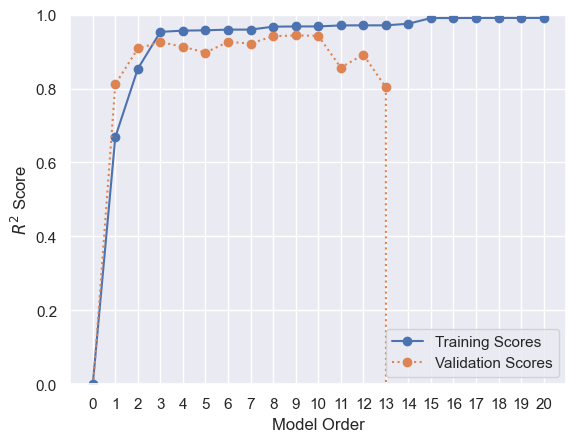

In [68]:
#create a for loop where you create, train, and evaluate multiple modes


#activity, add a comment to each line of code indicating what it is doing. 
train_scores = []
val_scores = []
model_order = []
for n in range(0,21):
    model = LinearRegression(fit_intercept=False)
    X_train = create_array_for_poly(x_train,n)
    model.fit(X_train,np.array(y_train).reshape(-1, 1))

    X_val = create_array_for_poly(x_val,n) 

    train_scores.append(model.score(X_train, np.array(y_train).reshape(-1, 1)))
    val_scores.append(model.score(X_val, np.array(y_val).reshape(-1, 1)))

    model_order.append(n)

    #print(f'Order {n}, coeffs = {model.coef_[0]}')

plt.plot(model_order, train_scores, 'o-', label = 'Training Scores')
plt.plot(model_order, val_scores, 'o:', label = 'Validation Scores')
plt.xlabel('Model Order')
plt.ylabel('$R^2$ Score')
plt.ylim([0,1])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
plt.legend()
    
    

According to our experiment, the best Model Order is 3; before that, the training score is still improving, meaning that the model is underfitting the training data. With model orders between 3 and 10, the validation score is pretty much stable, not showing many changes. After model order 10, the validation score starts to decay rapidly, indicating that the model is overfitting to the training data and no longer able to generalize. 

Let's see how this model order works in our data. 

Text(0.02, 0.91, 'validation score: $R^2$ = 0.93')

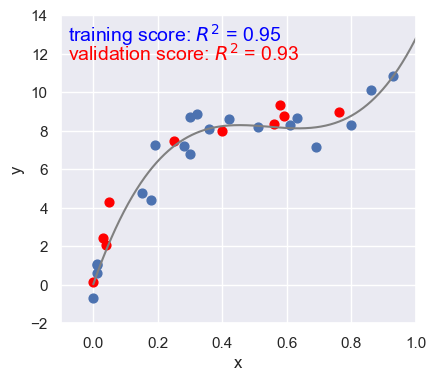

In [72]:
#fit the model
model2 = LinearRegression(fit_intercept=False) #the X matrix already has a column of 1 
X_train = create_array_for_poly(x_train,3) #create matrix with x and extra inputs 
model2.fit(X_train,np.array(y_train).reshape(-1, 1))
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
Xfit = create_array_for_poly(xfit,3)
yfit = model2.predict(Xfit)


#evaluate the model 
training_r2score = model2.score(X_train,np.array(y_train).reshape(-1, 1))
X_val = create_array_for_poly(x_val,3) #create matrix with x and extra inputs 
validation_r2score = model2.score(X_val,np.array(y_val).reshape(-1, 1))

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(x_train, y_train, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

ax.scatter(x_val, y_val, s=40, color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.02, 0.98, "training score: $R^2$ = {0:.2f}".format(training_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='blue')
ax.text(0.02, 0.91, "validation score: $R^2$ = {0:.2f}".format(validation_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='red')


### Cross-Validation

Selecting a single validation set can be misleading, as the validation data might not represent the training data or might be a restricted version of the training data. 

You could manually pick your validation data so that it is a good representation of the data set. However, this process could add bias and result in biased estimates. A more realistic approach is to have multiple validation sets, allowing you to train and evaluate multiple models.

<div style="text-align:center">
    <img src="images/cross-validation.png" alt="plot" width="400" />
</div>

This process is a vital component of machine learning as it allows us to obtain a realistic representation of the model's ability to explain the observed data. Libraries such as `scikit-learn` have functions built to train and evaluate models using cross-validation. 

Let's see how we can apply these principles to our data. 

In [88]:
from sklearn.model_selection import KFold

#all the data

x = np.array([0.3, 0.51, 0.36, 0.3, 0.18, 0.42, 0.19, 0.8, 0.93, 0.15, 0.63, 0.28, 0.32, 0.86, 0.01, 0.01, 0.0, 0.69, 0.61, 0.01, 0.59, 0.0, 0.4, 0.56, 0.25, 0.05, 0.04, 0.58, 0.03, 0.76])
y = np.array([8.7, 8.2, 8.09, 6.8, 4.38, 8.59, 7.26, 8.29, 10.84, 4.79, 8.66, 7.22, 8.86, 10.13, 0.6, 1.01, -0.67, 7.15, 8.3, 1.08, 8.77, 0.13, 8.01, 8.35, 7.48, 4.32, 2.05, 9.35, 2.41, 8.96])


k_folds = KFold(n_splits=5, shuffle=True, random_state=10)
fold_index = 1

training_r2score = []
validation_r2score = []

for train_index, val_index in k_folds.split(x):
    # These indices define your specific train and test sets for this fold
    x_train, x_val = x[train_index], x[val_index]
    y_train, y_val = y[train_index], y[val_index]

    #fit the model with the training data
    model = LinearRegression(fit_intercept=False) #the X matrix already has a column of 1 
    X_train = create_array_for_poly(x_train,3) #create matrix with x and extra inputs 
    model.fit(X_train ,y_train.reshape(-1, 1))
    training_r2score.append(model.score(X_train, y_train.reshape(-1, 1)))

    #evaluate the model 
    
    X_val = create_array_for_poly(x_val,3) #create matrix with x and extra inputs 
    validation_r2score.append(model.score(X_val,y_val.reshape(-1, 1)))
    
    #print the results for each cross-validation fold 
    print(f"Fold {fold_index}: Train size={len(X_train)}, Validation size={len(X_val)}")
    print(f"Training R^2 score = {np.round(training_r2score[-1],2)}, Validation R^2 score = {np.round(validation_r2score[-1],2)} \n")
    
    fold_index += 1

Fold 1: Train size=24, Validation size=6
Training R^2 score = 0.95, Validation R^2 score = 0.96 

Fold 2: Train size=24, Validation size=6
Training R^2 score = 0.94, Validation R^2 score = 0.97 

Fold 3: Train size=24, Validation size=6
Training R^2 score = 0.95, Validation R^2 score = 0.92 

Fold 4: Train size=24, Validation size=6
Training R^2 score = 0.95, Validation R^2 score = 0.92 

Fold 5: Train size=24, Validation size=6
Training R^2 score = 0.96, Validation R^2 score = 0.86 



Finally, you can present your cross-validation results using the mean, standard deviation, and 95% confidence interval.

In [89]:
#training set results 
mean_train = np.mean(training_r2score)
std_train = np.std(training_r2score)
prct5_train = np.percentile(training_r2score,2.5) #2.5 percentile 
prct95_train = np.percentile(training_r2score,97.5) #97.5 percentile
print(f"R^2 Training results = {mean_train.round(2)} +/- {std_train.round(2)}")
print(f"95%CI  = [{prct5_train.round(2)},{prct95_train.round(2)}]")

R^2 Training results = 0.95 +/- 0.01
95%CI  = [0.94,0.96]


In [90]:
#validation set results 
mean_val = np.mean(validation_r2score)
std_val = np.std(validation_r2score)
prct5_val = np.percentile(validation_r2score,2.5) #2.5 percentile 
prct95_val = np.percentile(validation_r2score,97.5) #97.5 percentile
print(f"R^2 Validation results = {mean_val.round(2)} +/- {std_val.round(2)}")
print(f"95%CI  = [{prct5_val.round(2)},{prct95_val.round(2)}]")

R^2 Validation results = 0.92 +/- 0.04
95%CI  = [0.86,0.97]


### Test and Validation Sets
A more realistic approach is to split your data into multiple sets. First, your original data is split into **train** and **test**. These sets are separated from the start of the experiment, and the test set is never used for training your data. Then, the train is used as part of a cross-validation approach to train the best model and identify the optimal model parameters. 

<div style="text-align:center">
    <img src="images/test-validation.png" alt="plot" width="400" />
</div>

This approach gives us three datasets with distinct uses:
- Train/validation set
    - Training set → learn parameters
    - Validation set → choose model
- Test set → estimate final performance

Note that the test is only used at the end, to provide a final performance test. 

This is a data-intensive procedure and is often overlooked when dealing with biomedical data due to the difficulties associated with building large datasets. However, failing to validate your model can lead to models that generalize poorly to new data and work well only with the data used for training. 

Let's see how this process works with our data. We are going to need a slightly larger dataset to properly train and test the model.

We will use `scikit-learn` tools for model testing and validation, which makes writing code much faster and less prone to errors  

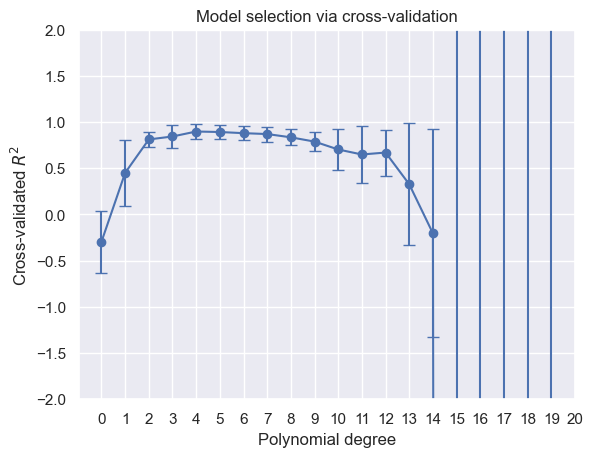

In [92]:
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# Data with 50 elements
# -----------------------------
N = 50
rseed = 42
err = 0.8

rng = np.random.RandomState(rseed)
X = rng.rand(N, 1) ** 2
y = 10 - 1. / (X.ravel() + 0.1)
if err > 0:
    y += err * rng.randn(N)

# -----------------------------
# Split the main data into train and test using train_test_split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=rseed)

# -----------------------------
# Generate a pipeline that: 1) creates a matrix with appropriate inputs, and 
# 2) fits a linear regression model and estimates the model parameters
# -----------------------------
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=True)),
    ("lr", LinearRegression())
])

# -----------------------------
# Set up the cross-validation 
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=rseed)

# -----------------------------
# Search for the optimal polynomial order using a grid search with orders from 1 to 20. 
# Use R2 score to evaluate your results
# -----------------------------
param_grid = {
    "poly__degree": list(range(0, 20))  #
}

#gridsearch will fit different models using a grid; you define what varies on the grid. In this case, only the degree of the polynomial 
#varies
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

#gridsearch will create train and validation sets internally to perform cross-validation. 
grid.fit(X_train, y_train)

# Extract results
degrees = grid.cv_results_["param_poly__degree"].data.astype(int)
mean_scores = grid.cv_results_["mean_test_score"]
std_scores = grid.cv_results_["std_test_score"]

# Sort by degree (GridSearchCV may not preserve order)
idx = np.argsort(degrees)
degrees = degrees[idx]
mean_scores = mean_scores[idx]
std_scores = std_scores[idx]

# Plot
plt.figure()
plt.errorbar(
    degrees,
    mean_scores,
    yerr=std_scores,
    marker='o',
    capsize=4
)
plt.xlabel("Polynomial degree")
plt.ylabel("Cross-validated $R^2$")
plt.title("Model selection via cross-validation")
plt.ylim([-2,2])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
plt.show()



After looking at the cross-validation results, we can see that the best model order is between 3 and 4. We can use 4 in this example. 

We can now use that model order, along with all the training data, to train and evaluate a final model. 

Text(0.02, 0.91, 'Test score: $R^2$ = 0.89')

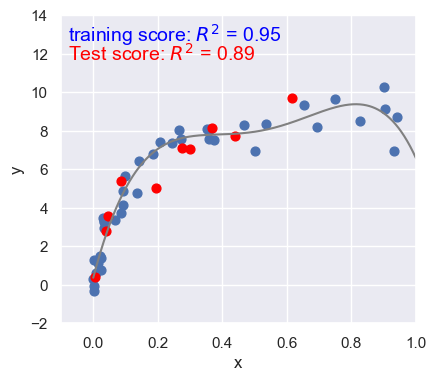

In [93]:
FinalPipe = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=True)),
    ("lr", LinearRegression())
])

FinalPipe.fit(X_train, y_train)
training_r2score = FinalPipe.score(X_train, y_train)
xfit = np.linspace(0, 1, 1000).reshape(-1, 1)
yfit = FinalPipe.predict(xfit)

#evaluate the model on the test data
validation_r2score = FinalPipe.score(X_test,y_test)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

ax.scatter(X_train, y_train, s=40)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot(xfit.ravel(), yfit, color='gray')
ax.axis([-0.1, 1.0, -2, 14])

ax.scatter(X_test, y_test, s=40, color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.02, 0.98, "training score: $R^2$ = {0:.2f}".format(training_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='blue')
ax.text(0.02, 0.91, "Test score: $R^2$ = {0:.2f}".format(validation_r2score),
           ha='left', va='top', transform=ax.transAxes, size=14, color='red')


### What Did We Learn About Model Evaluation?

Through these examples, we saw that:

- Models can perform extremely well on training data and still fail on new data
- Increasing model complexity improves training performance but can hurt generalization
- Validation data helps us choose among competing models
- Having independent validation and test sets provides an unbiased estimate of real-world performance

These observations are not specific to linear regression—they apply to all machine-learning models.

### Key Takeaways

- Training performance measures how well a model fits known data
- Validation performance guides model selection
- Test performance estimates generalization

Proper data separation prevents overfitting and data leakage

These principles form the foundation of trustworthy machine learning.


# WARNING!!! Data Leakage

Data leakage is one of the main reasons for overly optimistic model performance estimates in machine learning. It is also one of the main reasons for paper rejections.

Data leakage occurs whenever information from outside the training process is unintentionally used to build or tune a model. When this happens, the model appears to perform very well on the test set, but only because it has indirectly seen information it should not have access to.

As a result, performance estimates no longer reflect how the model will behave on truly unseen data.

### Common Ways Data Leakage Happens

Data leakage can occur in subtle ways, including:

- Using the test set to choose model parameters or complexity
- Performing data preprocessing (e.g., scaling, feature selection) before splitting the data
- Reusing the test set multiple times during model development
- Allowing information from future observations to influence past predictions

In all of these cases, the model benefits from information it would not have in real-world use.

### Why Data Leakage Is a Serious Problem

When data leakage occurs:
- Validation and test performance are artificially inflated
- Models appear more accurate than they truly are
- Results fail to replicate on new datasets
- Decisions based on these models can be misleading or harmful

Importantly, data leakage does not usually cause obvious errors in the code. The model runs correctly—but the conclusions are wrong.

### How to Prevent Data Leakage

To avoid data leakage:

- Always split the data into training and test sets before any model selection
- Perform preprocessing steps inside cross-validation or pipelines
- Use validation data only for model selection
- Evaluate the test set once, after all decisions are finalized

Scikit-learn pipelines help enforce these rules by ensuring that each step is learned only from the appropriate data.

Understanding and avoiding data leakage is essential for building machine-learning models that generalize reliably beyond the data used to develop them.